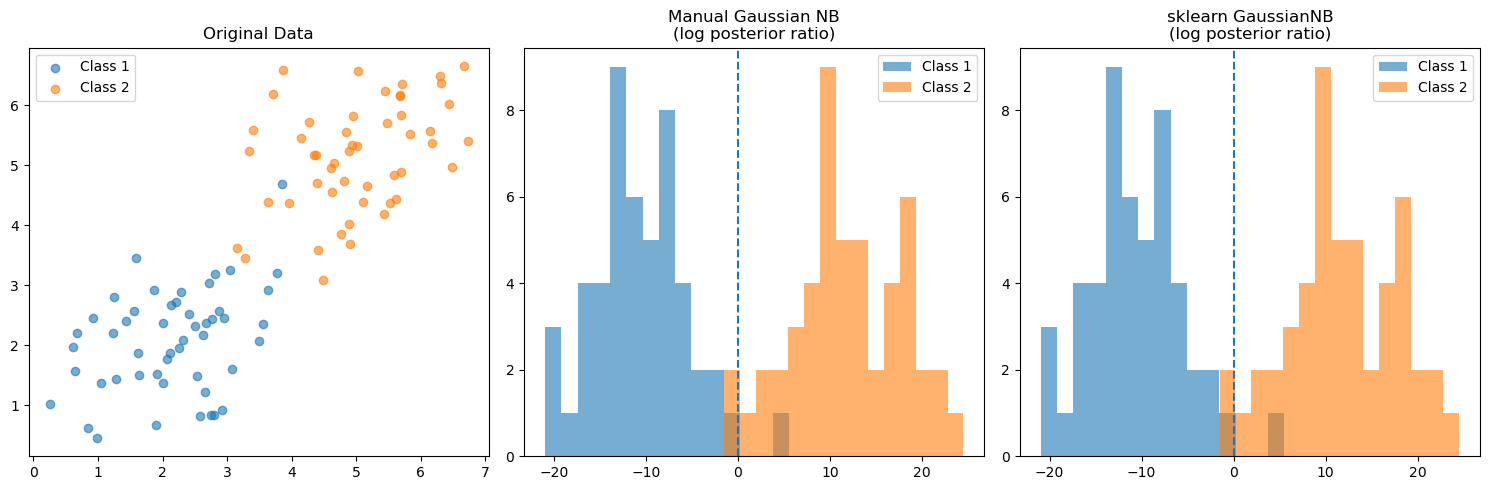

Manual Gaussian NB accuracy: 0.97
sklearn GaussianNB accuracy: 0.97


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB

# Generate two-class data
np.random.seed(42)
class1 = np.random.multivariate_normal(mean=[2, 2], cov=[[1, 0.5], [0.5, 1]], size=50)
class2 = np.random.multivariate_normal(mean=[5, 5], cov=[[1, 0.5], [0.5, 1]], size=50)

X = np.vstack([class1, class2])
y = np.array([0] * 50 + [1] * 50)

# -----------------------------
# Manual Gaussian Naive Bayes
# -----------------------------
# Compute class-wise means and variances for each feature
mean1 = np.mean(class1, axis=0)
mean2 = np.mean(class2, axis=0)

var1 = np.var(class1, axis=0)
var2 = np.var(class2, axis=0)

# Class priors
prior1 = len(class1) / len(X)
prior2 = len(class2) / len(X)

def gaussian_logpdf(x, mean, var):
    return -0.5 * np.sum(np.log(2 * np.pi * var) + ((x - mean) ** 2) / var, axis=1)

# Compute log-posterior scores
log_post1 = gaussian_logpdf(X, mean1, var1) + np.log(prior1)
log_post2 = gaussian_logpdf(X, mean2, var2) + np.log(prior2)

# Prediction
y_pred_manual = (log_post2 > log_post1).astype(int)

# For visualization: difference in log-posterior
score_manual = log_post2 - log_post1

# -----------------------------
# sklearn Gaussian Naive Bayes
# -----------------------------
gnb = GaussianNB()
gnb.fit(X, y)

y_pred_sklearn = gnb.predict(X)
score_sklearn = gnb.predict_log_proba(X)[:, 1] - gnb.predict_log_proba(X)[:, 0]

# -----------------------------
# Visualization
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot original data
axes[0].scatter(class1[:, 0], class1[:, 1], label='Class 1', alpha=0.6)
axes[0].scatter(class2[:, 0], class2[:, 1], label='Class 2', alpha=0.6)
axes[0].set_title("Original Data")
axes[0].legend()

# Manual Gaussian NB score distribution
axes[1].hist(score_manual[y == 0], alpha=0.6, label='Class 1', bins=15)
axes[1].hist(score_manual[y == 1], alpha=0.6, label='Class 2', bins=15)
axes[1].axvline(0, linestyle='--')
axes[1].set_title("Manual Gaussian NB\n(log posterior ratio)")
axes[1].legend()

# sklearn Gaussian NB score distribution
axes[2].hist(score_sklearn[y == 0], alpha=0.6, label='Class 1', bins=15)
axes[2].hist(score_sklearn[y == 1], alpha=0.6, label='Class 2', bins=15)
axes[2].axvline(0, linestyle='--')
axes[2].set_title("sklearn GaussianNB\n(log posterior ratio)")
axes[2].legend()

plt.tight_layout()
plt.show()

# Accuracy
manual_acc = np.mean(y_pred_manual == y)
sklearn_acc = np.mean(y_pred_sklearn == y)

print("Manual Gaussian NB accuracy:", manual_acc)
print("sklearn GaussianNB accuracy:", sklearn_acc)
